# MSE802 Quantum Computing: Assessment 2

## Task 1: Entanglement Demonstrations

The objective of this task is to construct the entangled Bell state

$$|\psi\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right)$$

in Cirq (Cirq Developers, n.d.), to verify it on a local simulator, and subsequently to execute it on the Quokka quantum device (Quokka Computing, n.d.). The circuit is built and simulated in Cirq, whereas Qiskit (Qiskit Contributors, n.d.) is used for the visualisation, since it provides a more complete set of state-visualisation tools.

In [1]:
'''libraries'''
import cirq
import requests
from qiskit import qasm2 
from collections import Counter
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit.visualization import plot_histogram, plot_distribution
from IPython.display import display

## Bell State: H and CNOT

Starting from the initial state $|00\rangle$, two gates are applied in order to obtain the Bell state:

1. The Hadamard gate on q0 creates an equal superposition:
$$|00\rangle \xrightarrow{H_0} \tfrac{1}{\sqrt2}(|00\rangle+|10\rangle)$$
2. The CNOT gate, with q0 as control and q1 as target, flips q1 only when q0 = 1:
$$\tfrac{1}{\sqrt2}(|00\rangle+|10\rangle) \xrightarrow{\text{CNOT}} \tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$$

The result is the Bell state $|\Phi^+\rangle$, one of the four maximally entangled two-qubit states (Nielsen & Chuang, 2010); consequently, the measurement outcomes of the two qubits are perfectly correlated.

## 1. Build the Circuit in Cirq

In [2]:
# Two qubits
q0, q1 = cirq.LineQubit.range(2)

# Build the Bell-state circuit
bell_state = cirq.Circuit()
bell_state.append(cirq.H(q0))             # Step 1: Hadamard -> superposition on q0
bell_state.append(cirq.CNOT(q0, q1))      # Step 2: CNOT -> entangle q1 with q0
bell_state.append(cirq.measure(q0, q1, key="result"))   # measure both qubits

print(bell_state)

0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────


## 2. Inspect the State Vector (Before Measurement)

Before any measurement is applied, the amplitudes of the state can be inspected in order to confirm that they correspond to $\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$.

In [3]:
# measurement to inspect the amplitudes before measurement.
prep = cirq.Circuit([cirq.H(q0), cirq.CNOT(q0, q1)])
state_vector = cirq.Simulator().simulate(prep)

print("State vector:", state_vector.dirac_notation())   # expect 0.71|00> + 0.71|11>
print("Amplitudes :", state_vector.final_state_vector)

State vector: 0.71|00⟩ + 0.71|11⟩
Amplitudes : [0.70710677+0.j 0.        +0.j 0.        +0.j 0.70710677+0.j]


## 4. Run on the Local Simulator (1000 Shots)

In order to verify the entanglement, the circuit is executed with 1000 repetitions. The only outcomes that should appear are `00` and `11`, each with a probability of approximately 50%; the outcomes `01` and `10` should never occur.

In [4]:
result_Cirq = cirq.Simulator().run(bell_state, repetitions=1000)
counts = result_Cirq.histogram(key="result")

# Relabel the integer keys (0->'00', 3->'11') as readable bitstrings
Cirq_counts = {format(k, "02b"): v for k, v in counts.items()}
print("Counts:", Cirq_counts)

Counts: {'11': 497, '00': 503}


## 5. Visualise the Results (Using Qiskit Features)

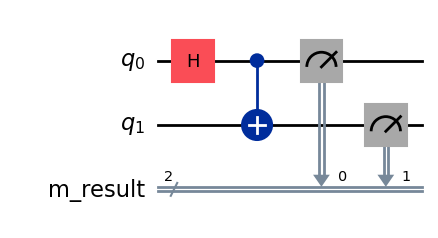

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

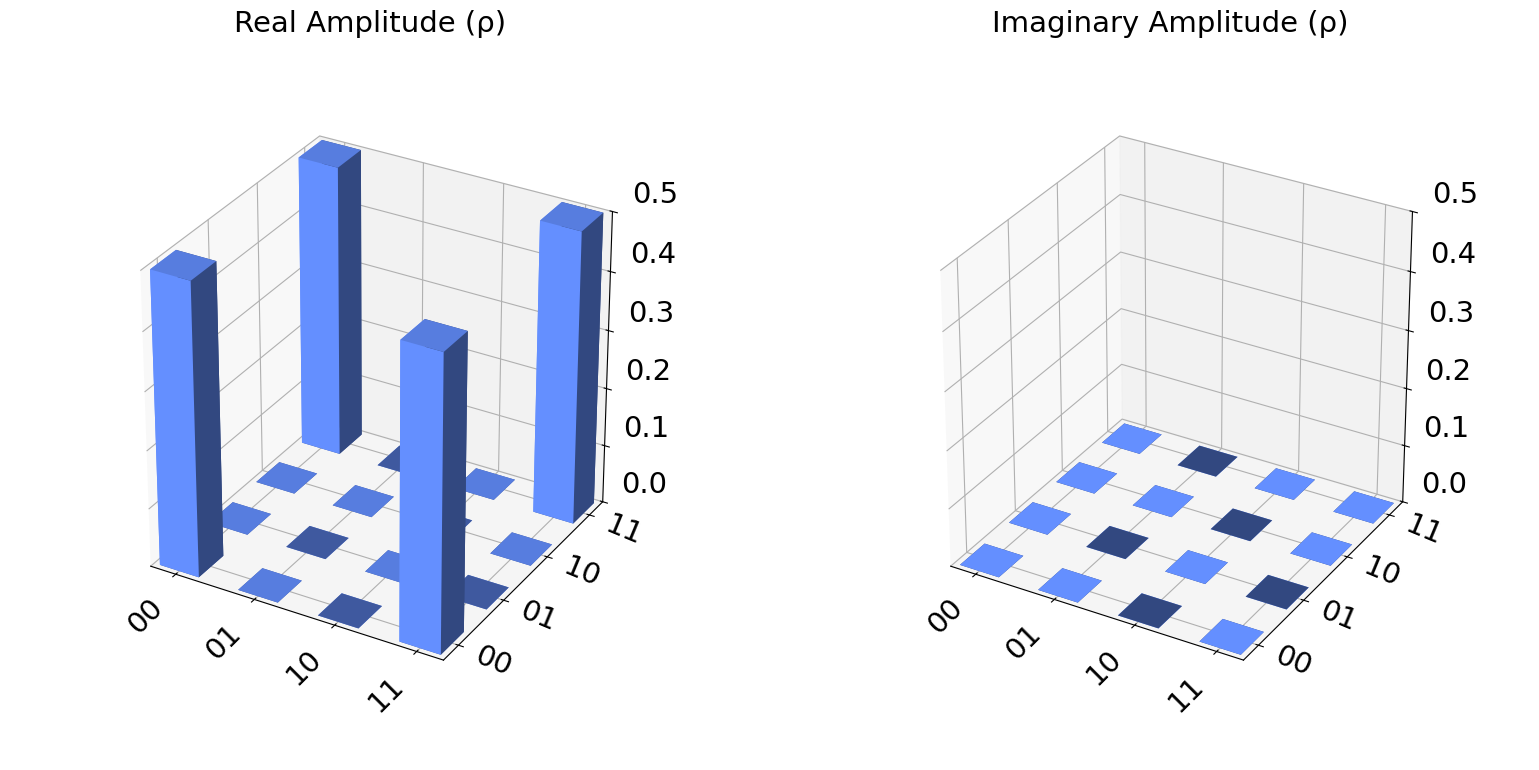

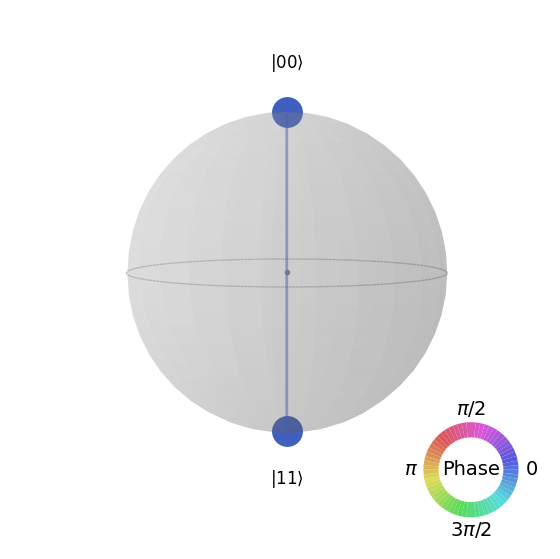

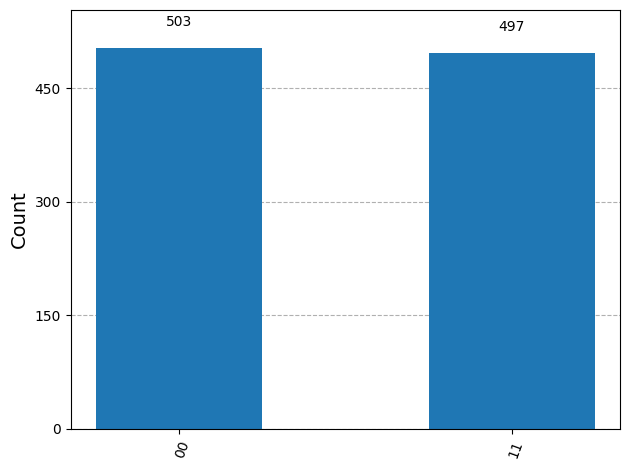

In [5]:
''' --- Visualisation via Qiskit ---
# Cirq builds and runs the circuit; Qiskit is used only to render the rich views.'''


# Load the Cirq circuit's QASM into Qiskit (used for both the drawing and the statevector)


qc_pic = qasm2.loads(bell_state.to_qasm())

# Build the statevector from the circuit (float64) so the LaTeX shows clean values
# (sqrt2/2, 1/2). Cirq's final_state_vector is float32, which renders as ugly decimals.
qc_state = qc_pic.remove_final_measurements(inplace=False)   # statevector needs no measurement

psi = Statevector(qc_state)

display(qc_pic.draw("mpl"))                # circuit diagram
display(psi.draw("latex"))                 # state vector as a ket
display(DensityMatrix(psi).draw("latex"))  # density matrix
display(psi.draw("city"))                  # state-city plot
display(psi.draw("qsphere"))               # Q-sphere
display(plot_histogram(Cirq_counts))          # measurement counts (from the Cirq run)

**Observation.** Only `00` and `11` occur, at approximately 50% each, while `01` and `10` are absent. Although each qubit is individually random, the two qubits are perfectly correlated; this correlation is the experimental signature of entanglement.

---
## Step 2: Run on the Quokka Quantum Device

The Quokka device does not run Cirq directly; therefore, the circuit is exported to OpenQASM 2.0 text and sent to the device's HTTP API through a `POST` request. Two practical considerations must be taken into account. First, the Quokka does not provide the `qelib1.inc` gate library, so the corresponding `include` line has to be removed before the script is sent. Second, the device is exposed through a rotating ngrok URL that is only available during class or on the college network; it is therefore necessary to update the device URL below (`req_str_qasm`) with the address provided by the tutor.

### 2.1 Export the Cirq Circuit to Clean QASM

In [6]:
print("Cirq", bell_state)
# Convert the Cirq circuit to OpenQASM 2.0 string
qasm_string = cirq.qasm(bell_state)
print("Cirq QASM 2.0:\n", qasm_string)
# Write the string to a text file
with open("Task-1_Bel-State.qasm", "w") as file:
    file.write(qasm_string)

print("File saved successfully as 'Task-1_Bel-State.qasm'!")

Cirq 0: ───H───@───M('result')───
          │   │
1: ───────X───M─────────────
Cirq QASM 2.0:
 // Generated from Cirq v1.6.1

OPENQASM 2.0;
include "qelib1.inc";


// Qubits: [q(0), q(1)]
qreg q[2];
creg m_result[2];


h q[0];
cx q[0],q[1];

// Gate: cirq.MeasurementGate(2, cirq.MeasurementKey(name='result'), ())
measure q[0] -> m_result[0];
measure q[1] -> m_result[1];

File saved successfully as 'Task-1_Bel-State.qasm'!


### 2.2 Importing QASM to Qiskit

OPENQASM 2.0;
qreg q[2];
creg m_result[2];
h q[0];
cx q[0],q[1];
measure q[0] -> m_result[0];
measure q[1] -> m_result[1];


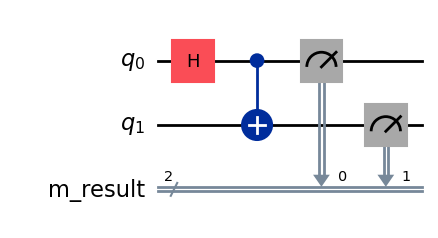

In [7]:
circuitS = qasm2.load("Task-1_Bel-State.qasm")
code = qasm2.dumps(circuitS)
code = code[:14] + code[(14 + 22):]

print(code)
display(circuitS.draw("mpl"))       

### 2.3 Run on the Quokka Device

In [8]:
req_str_qasm = "http://quokka3.quokkacomputing.com/qsim/qasm"

data = {
    'script': code,
    'count': 100
}

try:
    response = requests.post(req_str_qasm, json=data)
    
    # Catch non-200 responses before trying to parse JSON
    if response.status_code != 200:
        print(f"Server Error {response.status_code}: Server returned non-JSON data.")
        print("Response Snippet:", response.text[:200])
    else:
        results = response.json()
        print("Execution Results:", results)

    # Extract the raw list of shots
    raw_shots = results['result']['m_result']

    # Convert each [0, 0] or [1, 1] list into a string key like "00" or "11"
    string_shots = ["".join(map(str, shot)) for shot in raw_shots]

    # Aggregate into a dictionary of counts
    quokka_counts = dict(Counter(string_shots))

    print("Quokka device counts:", quokka_counts)
        
except Exception as e:
    print("Error communicating with Quokka:", e)

Execution Results: {'error': 'no error', 'error_code': 0, 'result': {'m_result': [[0, 0], [0, 0], [0, 0], [0, 0], [1, 1], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [0, 0], [1, 1], [0, 0], [1, 1], [0, 0], [1, 1], [0, 0], [0, 0], [0, 0], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [1, 1], [1, 1], [0, 0], [0, 0], [0, 0], [1, 1], [1, 1], [0, 0], [1, 1], [0, 0], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [1, 1], [0, 0], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [0, 0], [1, 1], [0, 0], [1, 1], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [1, 1], [0, 0], [0, 0], [1, 1], [0, 0], [0, 0], [0, 0], [0, 0], [1, 1], [0, 0], [0, 0], [1, 1], [1, 1], [0, 0], [0, 0]]}}
Quokka device counts: {'00': 53, '11': 47}


### 2.4 Cirq vs. Quokka

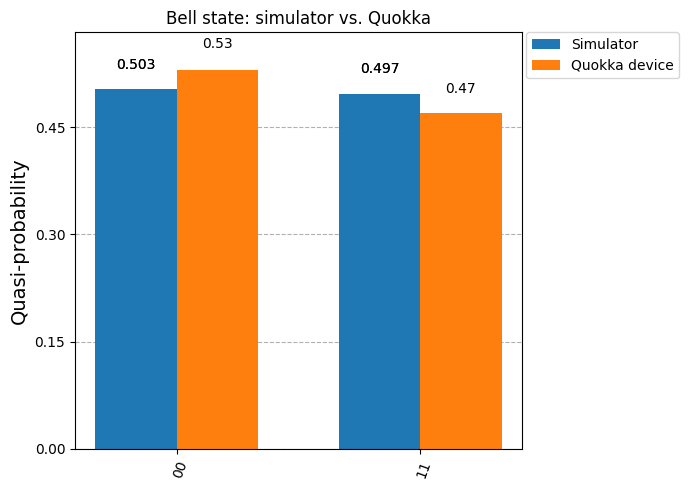

In [9]:
# Auto-normalizes each set to probabilities, so the 1000-shot sim and
# 100-shot device compare fairly (and it draws the grouped bars + legend).
plot_distribution([Cirq_counts, quokka_counts],
                  legend=["Simulator", "Quokka device"],
                  title="Bell state: simulator vs. Quokka")

### 2.5 Conclusion

The Bell state $\tfrac{1}{\sqrt2}(|00\rangle+|11\rangle)$ was constructed in Cirq, verified on the local simulator, where only the outcomes `00` and `11` were obtained, and subsequently executed on the Quokka device, which returned the same two outcomes at approximately 50% each and produced no spurious `01` or `10` counts. This result indicates that the device reproduces the entangled state that was designed in Cirq.

A genuinely noisy physical processor would normally show a small number of counts in the forbidden outcomes `01` and `10`; however, the Quokka results match those of the ideal simulator, which suggests that it behaves as an emulated, noise-free quantum device. Although the number of shots differs between the two runs, the comparison between the simulator and the device confirms that the measured distributions are statistically consistent, which supports the validity of the entangled state that was produced.

## References

Cirq Developers. (n.d.). *Cirq* (Version 1.6.1) [Computer software]. Google Quantum AI. Retrieved July 24, 2026, from https://quantumai.google/cirq

Nielsen, M. A., & Chuang, I. L. (2010). *Quantum computation and quantum information* (10th anniversary ed.). Cambridge University Press.

Qiskit Contributors. (n.d.). *Qiskit: An open-source framework for quantum computing* (Version 2.4.0) [Computer software]. IBM Quantum. Retrieved July 24, 2026, from https://www.ibm.com/quantum/qiskit

Quokka Computing. (n.d.). *Quokka quantum computer* [Apparatus]. Retrieved July 24, 2026, from https://www.quokkacomputing.com